In [63]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import contextily as ctx
import pandas as pd


pd.set_option('display.max_columns', 500)

In [64]:
with open('gdf_ht.pickle', 'rb') as file:
    gdf_ht =  pickle.load(file)

In [65]:
with open('warsaw.pickle', 'rb') as file:
    warsaw =  pickle.load(file)

In [66]:
with open('powiaty_maz.pickle', 'rb') as file:
    powiaty_maz =  pickle.load(file)

In [67]:
with open('dzielnice.pickle', 'rb') as file:
    dzielnice =  pickle.load(file)

In [68]:
with open('gdf.pickle', 'rb') as file:
    gdf =  pickle.load(file)

In [69]:
pkd7 = pd.read_excel('C:\\Studia\\Master\\master_thesis\\data\\PKD7_HT.xlsx')

In [70]:
pkd7

,PKD7,Group
0,0111Z,O
1,0112Z,O
2,0113Z,O
3,0114Z,O
4,0115Z,O
...,...,...
649,9609Z,O
650,9700Z,O
651,9810Z,O
652,9820Z,O


In [71]:
gdf = pd.merge(gdf, pkd7, on='PKD7', how='left')

In [105]:
gdf

,?,ID,REGON,POWIAT,GMINA,Address_full,SEK_PKD7,PKD7,GR_LPRAC,lon,lat,tech,if_hightech,empl,sharesEMPL2,ones,locPdens,locAggA,locAggB,locAggC,locAggD,locAggE,locAggF,locAggG,locAggH,locAggI,locAggJ,locAggK,locAggL,locAggM,locAggN,locAggO,locAggP,locAggQ,locAggR,locAggS,locAggT,locAggU,locHH,locBIG,locAggTOTAL,locHightech,locLQ,dist_core_10,dist_core_25,dist_core_50,dist_midsize_10,dist_midsize_25,dist_midsize_50,dist_regional_10,dist_regional_25,dist_regional_50,dist_localbig_10,dist_localbig_25,dist_localbig_50,dist_localsmall_10,dist_localsmall_25,dist_localsmall_50,COREfirms,COREpopul,geometry,Group
0,42342,1,1.406805e+13,17,44,Joachima Lelewela 27 05-480 Karczew,S,9499Z,1,21.23600,52.08347,other,0,5.034085,1.856614e-10,1,26,18,0,38,0,1,25,56,13,1,7,5,1,11,5,0,6,9,1,8,0,0,1.468536e-09,0,205,15,0.851179,0,1,1,0,0,0,0,0,1,1,1,1,0,1,1,1,1,POINT (21.23600 52.08347),O
1,42343,2,6.721748e+13,7,22,Rogożek 3 26-903 Rogożek,A,0150Z,1,21.36008,51.63636,other,0,5.035107,1.531587e-11,1,1,2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.994063e-11,0,3,0,2.586889,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,POINT (21.36008 51.63636),O
2,118240,3,1.109380e+12,65,58,Ignacego Krasickiego 12A 02-611 Warszawa,G,4690Z,1,21.02140,52.19191,other,0,5.001276,1.518227e-11,1,203,72,4,141,24,12,192,620,111,64,203,98,185,533,121,0,89,101,51,207,0,1,2.685278e-07,34,2829,183,1.126141,1,1,1,0,0,0,0,1,1,0,1,1,1,1,1,1,1,POINT (21.02140 52.19191),O
3,210007,4,1.566525e+12,65,188,al. Prymasa Tysiąclecia 62 01-424 Warszawa,G,4643Z,1,20.95726,52.23474,other,0,5.114140,1.587524e-11,1,220,10,1,35,3,4,47,133,25,27,42,19,54,111,29,3,25,24,12,38,0,0,3.089481e-08,6,642,49,1.064512,1,1,1,0,0,0,0,1,1,0,1,1,0,1,1,1,1,POINT (20.95726 52.23474),O
4,423467,5,1.401995e+13,65,48,Marymoncka 93/97 01-813 Warszawa,S,9511Z,1,20.95403,52.28521,other,0,4.939015,1.787151e-10,1,150,50,0,172,2,2,166,505,110,59,143,66,105,323,104,1,106,111,69,164,0,0,5.495024e-07,16,2258,141,1.584181,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,POINT (20.95403 52.28521),MLT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
983714,848910,983715,6.700468e+13,63,11,Adama Mickiewicza 15A 26-600 Radom,K,6492Z,1,21.15541,51.39728,other,0,5.051210,5.576468e-10,1,171,304,5,450,4,12,397,1713,286,167,114,192,335,570,118,11,229,350,84,421,0,0,6.346276e-07,59,5762,157,1.332165,0,0,0,0,1,1,0,0,0,0,0,0,0,1,1,1,1,POINT (21.15541 51.39728),KIS
983715,948039,983716,1.403177e+13,65,108,Złota 59 00-120 Warszawa,F,4110Z,1,21.00245,52.23008,other,0,5.046067,9.670373e-11,1,197,115,21,417,106,25,608,1593,209,278,573,646,709,1843,315,13,132,172,110,587,0,6,2.378078e-06,116,8478,594,0.985588,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,POINT (21.00245 52.23008),O
983716,937486,983717,1.662122e+12,65,168,Arbuzowa 45 02-747 Warszawa,A,0150Z,1,21.06074,52.16853,other,0,4.993093,1.506134e-11,1,91,66,4,110,4,2,127,350,83,26,179,79,77,366,70,0,79,90,48,115,0,2,9.951653e-10,6,1877,181,0.136442,1,1,1,0,0,0,0,0,1,0,1,1,1,1,1,1,1,POINT (21.06074 52.16853),O
983717,907962,983718,2.041457e+11,65,118,Rusiecka 10 03-698 Warszawa,C,1812Z,1,21.07733,52.29214,other,0,5.006657,5.524592e-11,1,48,21,1,111,0,0,95,304,80,27,80,34,36,140,48,1,39,39,17,66,0,0,7.687505e-08,5,1139,87,1.629730,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,POINT (21.07733 52.29214),LT


In [72]:
gdf['tech'].fillna('other', inplace=True)

In [11]:
gdf['Group'].value_counts()

Group
O        718731
KIS      131016
HTKIS     56774
MLT       37023
LT        30192
MHT        5862
HT         2173
PMHT       1944
Name: count, dtype: int64

In [73]:
one_hot_encoded = pd.get_dummies(gdf['Group'])

# Convert boolean values to integers (0 and 1)
one_hot_encoded = one_hot_encoded.astype(int)

# Concatenate the original DataFrame with the one-hot encoded DataFrame
df_encoded = pd.concat([gdf, one_hot_encoded], axis=1)

df_encoded.head()

,?,ID,REGON,POWIAT,GMINA,Address_full,SEK_PKD7,PKD7,GR_LPRAC,lon,lat,tech,if_hightech,empl,sharesEMPL2,ones,locPdens,locAggA,locAggB,locAggC,locAggD,locAggE,locAggF,locAggG,locAggH,locAggI,locAggJ,locAggK,locAggL,locAggM,locAggN,locAggO,locAggP,locAggQ,locAggR,locAggS,locAggT,locAggU,locHH,locBIG,locAggTOTAL,locHightech,locLQ,dist_core_10,dist_core_25,dist_core_50,dist_midsize_10,dist_midsize_25,dist_midsize_50,dist_regional_10,dist_regional_25,dist_regional_50,dist_localbig_10,dist_localbig_25,dist_localbig_50,dist_localsmall_10,dist_localsmall_25,dist_localsmall_50,COREfirms,COREpopul,geometry,Group,HT,HTKIS,KIS,LT,MHT,MLT,O,PMHT
0,42342,1,1.406805e+13,17,44,Joachima Lelewela 27 05-480 Karczew,S,9499Z,1,21.23600,52.08347,other,0,5.034085,1.856614e-10,1,26,18,0,38,0,1,25,56,13,1,7,5,1,11,5,0,6,9,1,8,0,0,1.468536e-09,0,205,15,0.851179,0,1,1,0,0,0,0,0,1,1,1,1,0,1,1,1,1,POINT (21.23600 52.08347),O,0,0,0,0,0,0,1,0
1,42343,2,6.721748e+13,7,22,Rogożek 3 26-903 Rogożek,A,0150Z,1,21.36008,51.63636,other,0,5.035107,1.531587e-11,1,1,2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.994063e-11,0,3,0,2.586889,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,POINT (21.36008 51.63636),O,0,0,0,0,0,0,1,0
2,118240,3,1.109380e+12,65,58,Ignacego Krasickiego 12A 02-611 Warszawa,G,4690Z,1,21.02140,52.19191,other,0,5.001276,1.518227e-11,1,203,72,4,141,24,12,192,620,111,64,203,98,185,533,121,0,89,101,51,207,0,1,2.685278e-07,34,2829,183,1.126141,1,1,1,0,0,0,0,1,1,0,1,1,1,1,1,1,1,POINT (21.02140 52.19191),O,0,0,0,0,0,0,1,0
3,210007,4,1.566525e+12,65,188,al. Prymasa Tysiąclecia 62 01-424 Warszawa,G,4643Z,1,20.95726,52.23474,other,0,5.114140,1.587524e-11,1,220,10,1,35,3,4,47,133,25,27,42,19,54,111,29,3,25,24,12,38,0,0,3.089481e-08,6,642,49,1.064512,1,1,1,0,0,0,0,1,1,0,1,1,0,1,1,1,1,POINT (20.95726 52.23474),O,0,0,0,0,0,0,1,0
4,423467,5,1.401995e+13,65,48,Marymoncka 93/97 01-813 Warszawa,S,9511Z,1,20.95403,52.28521,other,0,4.939015,1.787151e-10,1,150,50,0,172,2,2,166,505,110,59,143,66,105,323,104,1,106,111,69,164,0,0,5.495024e-07,16,2258,141,1.584181,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,POINT (20.95403 52.28521),MLT,0,0,0,0,0,1,0,0


if_hightech = high-tech, medium high-tech, knowledge intensive

In [74]:
warsaw_ht = warsaw[warsaw['if_hightech'] == 1]

In [75]:
import math

lon = 21.017532
lat = 52.237049


one_km_in_degrees_lat = 5 / 111.32
one_km_in_degrees_lon = 5 / (111.32 * math.cos(math.radians(lat)))

grid_size = min(one_km_in_degrees_lat, one_km_in_degrees_lon)

print("Grid Size for Approximately 1 km Grid:", grid_size, "degrees")

average_grid_size = (one_km_in_degrees_lat + one_km_in_degrees_lon) / 2

print("Average Grid Size for Approximately 1 km Grid:", average_grid_size, "degrees")


Grid Size for Approximately 1 km Grid: 0.044915558749550846 degrees
Average Grid Size for Approximately 1 km Grid: 0.0591297689745963 degrees


In [76]:
gdf_ht = gdf[gdf['if_hightech'] == 1]

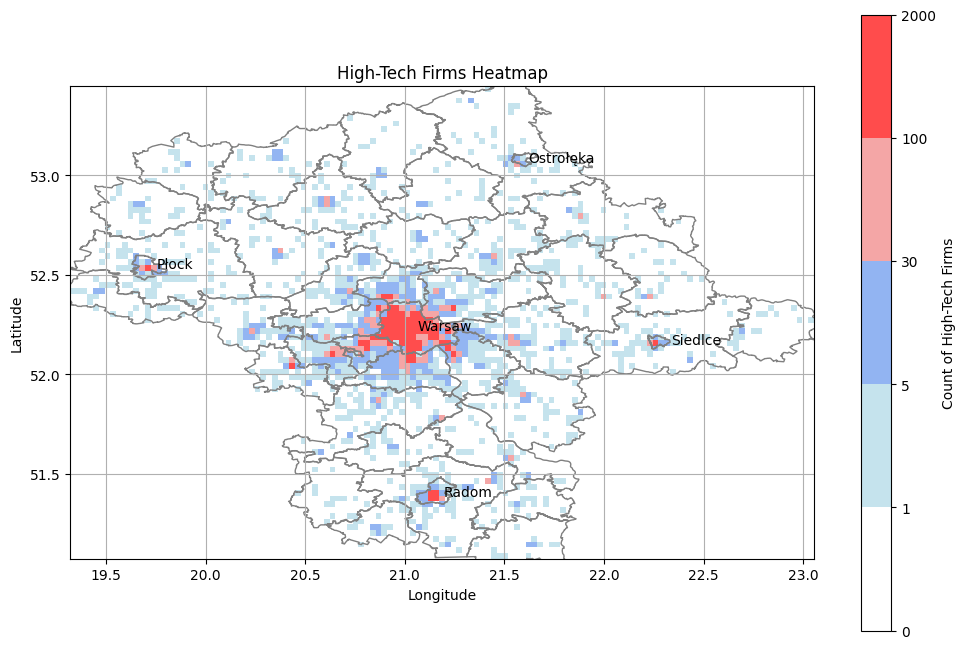

In [83]:
min_lon_maz, max_lon_maz = gdf_ht['lon'].min(), gdf_ht['lon'].max()
min_lat_maz, max_lat_maz = gdf_ht['lat'].min(), gdf_ht['lat'].max()
grid_size = 0.02912

lons_maz = np.arange(min_lon_maz, max_lon_maz, grid_size)
lats_maz = np.arange(min_lat_maz, max_lat_maz, grid_size)

gdf_ht['grid_x_maz_ht'] = np.digitize(gdf_ht['lon'], lons_maz)
gdf_ht['grid_y_maz_ht'] = np.digitize(gdf_ht['lat'], lats_maz)

grid_counts_maz = gdf_ht.groupby(['grid_x_maz_ht', 'grid_y_maz_ht']).size().reset_index(name='firm_count_maz_ht')
gdf_ht = gdf_ht.merge(grid_counts_maz, how='left', on=['grid_x_maz_ht', 'grid_y_maz_ht'])

heatmap_maz = np.zeros((len(lats_maz), len(lons_maz)))

for idx, row in grid_counts_maz.iterrows():
    grid_x, grid_y = row['grid_x_maz_ht'] - 1, row['grid_y_maz_ht'] - 1  
    count = row['firm_count_maz_ht']
    heatmap_maz[grid_y, grid_x] = count


city_lon = [21.017532, 21.14714, 19.70638, 22.29006, 21.5714]
city_lat = [52.237049, 51.40253, 52.54682, 52.16772, 53.0813]
city_names = ['Warsaw', 'Radom', 'Płock', 'Siedlce', 'Ostrołęka']

colors = ['white', 'lightblue', 'cornflowerblue', 'lightcoral', 'red']
bounds = [0, 1, 5, 30, 100, 2000]

cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, len(colors))

ax = powiaty_maz.plot(figsize=(12, 8), color='none', edgecolor='grey')

plt.imshow(heatmap_maz, cmap=cmap, norm=norm, origin='lower', extent=[min_lon_maz, max_lon_maz, min_lat_maz, max_lat_maz], alpha=0.7)

for city, lon, lat in zip(city_names, city_lon, city_lat):
    plt.annotate(city, xy=(lon, lat), xytext=(7, -2), textcoords='offset points', color='black', fontsize=10)

plt.colorbar(label='Count of High-Tech Firms')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('High-Tech Firms Heatmap')

plt.grid(True)
plt.show()


Radius 500m maz

In [61]:
import geopandas as gpd
from shapely.geometry import Point

radius =  0.00734 
gdf_ht['buffer'] = gdf_ht.geometry.buffer(radius)

target_variable = []

for index, location in gdf_ht.iterrows():
    high_tech_firms_within_radius = gdf_ht[gdf_ht.geometry.within(location['buffer'])]
    num_high_tech_firms = len(high_tech_firms_within_radius)
    target_variable.append(num_high_tech_firms)

gdf_ht['high_tech_firm_clustering'] = target_variable


In [62]:
gdf_ht

,?,ID,REGON,POWIAT,GMINA,Address_full,SEK_PKD7,PKD7,GR_LPRAC,lon,lat,tech,if_hightech,empl,sharesEMPL2,ones,locPdens,locAggA,locAggB,locAggC,locAggD,locAggE,locAggF,locAggG,locAggH,locAggI,locAggJ,locAggK,locAggL,locAggM,locAggN,locAggO,locAggP,locAggQ,locAggR,locAggS,locAggT,locAggU,locHH,locBIG,locAggTOTAL,locHightech,locLQ,dist_core_10,dist_core_25,dist_core_50,dist_midsize_10,dist_midsize_25,dist_midsize_50,dist_regional_10,dist_regional_25,dist_regional_50,dist_localbig_10,dist_localbig_25,dist_localbig_50,dist_localsmall_10,dist_localsmall_25,dist_localsmall_50,COREfirms,COREpopul,geometry,buffer,high_tech_firm_clustering
51,131003,52,1.422096e+13,65,198,Filarecka 3 01-582 Warszawa,C,2899Z,1,20.98255,52.26879,medium-high-tech,1,4.990720,5.489477e-11,1,181,49,2,129,13,9,173,455,81,59,164,95,146,419,83,4,61,76,41,120,0,1,2.780316e-07,26,2180,172,0.989577,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,POINT (20.98255 52.26879),"POLYGON ((20.98989 52.26879, 20.98985 52.26807...",237
55,1422,56,1.232439e+12,34,41,Lipowa 6 05-220 Zielonka,C,3250Z,1,21.15484,52.31377,medium-high-tech,1,4.963468,5.429690e-11,1,47,52,0,105,0,5,106,240,44,29,32,23,40,92,45,3,35,53,21,59,0,0,2.122639e-08,3,984,35,1.784476,0,1,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,POINT (21.15484 52.31377),"POLYGON ((21.16218 52.31377, 21.16214 52.31305...",23
60,379416,61,1.562451e+12,65,178,Przednia 5 02-433 Warszawa,J,6209Z,1,20.90713,52.21079,high-tech know-intens serv,1,4.942834,3.112533e-10,1,61,43,0,138,1,7,137,404,101,32,84,34,64,166,51,0,40,35,21,56,0,0,6.046355e-08,6,1414,99,1.505300,0,1,1,0,0,0,0,1,1,0,1,1,1,1,1,1,1,POINT (20.90713 52.21079),"POLYGON ((20.91447 52.21079, 20.91443 52.21007...",76
79,4897,80,1.425502e+13,12,75,Zastawie 12 05-074 Kazimierów,J,6311Z,1,21.37159,52.23490,high-tech know-intens serv,1,4.938039,3.106498e-10,1,8,29,0,5,0,0,9,5,2,0,5,3,0,6,2,0,1,1,0,3,0,0,1.273808e-08,1,71,4,1.784452,0,1,1,0,0,0,0,0,1,0,1,1,1,1,1,0,1,POINT (21.37159 52.23490),"POLYGON ((21.37893 52.23490, 21.37889 52.23418...",4
104,678310,105,1.425899e+13,65,58,Skrzetuskiego 42 02-726 Warszawa,J,6312Z,1,21.02519,52.17849,high-tech know-intens serv,1,4.948453,3.119614e-10,1,188,109,13,238,35,4,286,1068,166,94,506,204,200,816,196,1,139,210,60,201,0,1,6.820227e-07,32,4547,496,2.819803,1,1,1,0,0,0,0,1,1,0,1,1,1,1,1,1,1,POINT (21.02519 52.17849),"POLYGON ((21.03253 52.17849, 21.03249 52.17777...",426
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
983588,13783,983589,1.470686e+13,38,11,Wojska Polskiego 10 96-300 Żyrardów,J,6202Z,1,20.44752,52.04410,high-tech know-intens serv,1,5.042388,3.239175e-10,1,22,43,0,47,0,2,53,204,24,17,9,6,15,28,15,0,3,14,5,25,0,0,2.859560e-09,2,510,12,0.447163,0,0,1,0,0,0,0,1,1,1,1,1,0,1,1,1,1,POINT (20.44752 52.04410),"POLYGON ((20.45486 52.04410, 20.45482 52.04338...",10
983632,340722,983633,1.460059e+13,20,11,Grunwaldzka 8D 09-100 Płońsk,J,6203Z,1,20.37799,52.62490,high-tech know-intens serv,1,5.041686,3.238275e-10,1,81,141,0,85,0,2,77,381,36,35,18,42,56,98,21,13,44,64,11,116,0,0,5.744003e-09,12,1240,27,0.367827,0,0,0,0,0,0,0,0,1,0,0,1,1,1,1,1,1,POINT (20.37799 52.62490),"POLYGON ((20.38533 52.62490, 20.38529 52.62418...",20
983651,344972,983652,1.123418e+12,65,48,Renesansowa 25 01-905 Warszawa,J,6203Z,1,20.93223,52.27665,high-tech know-intens serv,1,5.047380,3.245592e-10,1,252,198,2,303,2,2,411,1048,370,90,276,162,90,747,181,0,176,213,73,273,0,0,1.212904e-07,20,4617,285,1.514755,0,1,1,0,0,0,0,1,1,0,1,1,1,1,1,1,1,POINT (20.93223 52.27665),"POLYGON ((20.93957 52.27665, 20.93953 52.27593...",169
983671,19332,983672,1.463355e+13,65,148,Michała Kajki 41/43 04-634 Warszawa,J,6201Z,1,21.16481,52.21526,high-tech know-intens serv,1,4.982237,3.162356e-10,1,31,24,0,92,1,5,68,239,37,27,45,31,48,141,23,0,32,58,13,65,0,0,2.549273e-08,6,949,50,1.201543,1,1,1,0,0,0,0,0,1,

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Polygon
from mpl_toolkits.axes_grid1 import make_axes_locatable  # Import this module for colorbar

# Define colors for the clustering levels
colors = ['white', 'lightblue', 'cornflowerblue', 'lightcoral', 'red']
bounds = [0, 1, 3, 7, 15, 50]
cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, len(colors))

# Plot the administrative boundaries
fig, ax = plt.subplots(figsize=(12, 8))
powiaty_maz.plot(ax=ax, color='none', edgecolor='grey')

# Overlay the heatmap of high-tech firm clustering
gdf_ht.plot(ax=ax, column='high_tech_firm_clustering', cmap=cmap, norm=norm, markersize=2, alpha=0.5)

# Annotate cities
for city, lon, lat in zip(city_names, city_lon, city_lat):
    ax.annotate(city, xy=(lon, lat), xytext=(7, -2), textcoords='offset points', color='black', fontsize=10)

# Create a scalar mappable
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Dummy array for the colorbar

# Add colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label('Count of High-Tech Firms')

# Set plot title and labels
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('High-Tech Firms Heatmap')

plt.grid(True)
plt.show()

In [ ]:
powiaty_maz.columns = ['Powiat', 'geometry']

Silhouette score plot

In [ ]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

X = gdf_ht[['lon', 'lat']].values

# Define range of parameters to search
eps_values = np.arange(0.01, 0.1, 0.01) # Adjust according to your data
min_samples_values = [40, 50, 60, 65, 70, 75, 80]  # Adjust according to your data

# Initialize variables to store silhouette scores
silhouette_scores = []

# Loop through all combinations of eps and min_samples
for eps in eps_values:
    for min_samples in min_samples_values:
        # Initialize DBSCAN with current parameters
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X)
        
        # Compute silhouette score
        silhouette = silhouette_score(X, labels)
        silhouette_scores.append(silhouette)

# Reshape silhouette scores for plotting
silhouette_scores = np.array(silhouette_scores).reshape(len(eps_values), len(min_samples_values))

# Plotting
plt.figure(figsize=(10, 6))
for i, eps in enumerate(eps_values):
    plt.plot(min_samples_values, silhouette_scores[i], marker='o', label=f'eps = {eps}')

plt.title('Elbow Plot for Silhouette Score')
plt.xlabel('min_samples')
plt.ylabel('Silhouette Score')
plt.legend(title='eps')
plt.grid(True)
plt.xticks(min_samples_values)
plt.show()



Best Silhouette score

In [ ]:
best_eps = None
best_min_samples = None
best_silhouette_score = -1  # Initialize with a value lower than the possible silhouette score range

# Loop through all combinations of eps and min_samples
for eps in eps_values:
    for min_samples in min_samples_values:
        # Initialize DBSCAN with current parameters
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X)
        
        # Check if only one cluster is found
        if len(np.unique(labels)) <= 1:
            continue
        
        # Compute silhouette score
        silhouette = silhouette_score(X, labels)
        
        # Update best parameters and silhouette score if current silhouette score is higher
        if silhouette > best_silhouette_score:
            best_eps = eps
            best_min_samples = min_samples
            best_silhouette_score = silhouette

# Print the best parameters and silhouette score
print(f"Best eps: {best_eps}")
print(f"Best min_samples: {best_min_samples}")
print(f"Best silhouette score: {best_silhouette_score}")

In [ ]:
# Best eps: 0.08
# Best min_samples: 65
# Best silhouette score: 0.638864600847597

Final DBSCAN 

Labels: [0 0 0 ... 0 0 0]
Unique Labels: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]


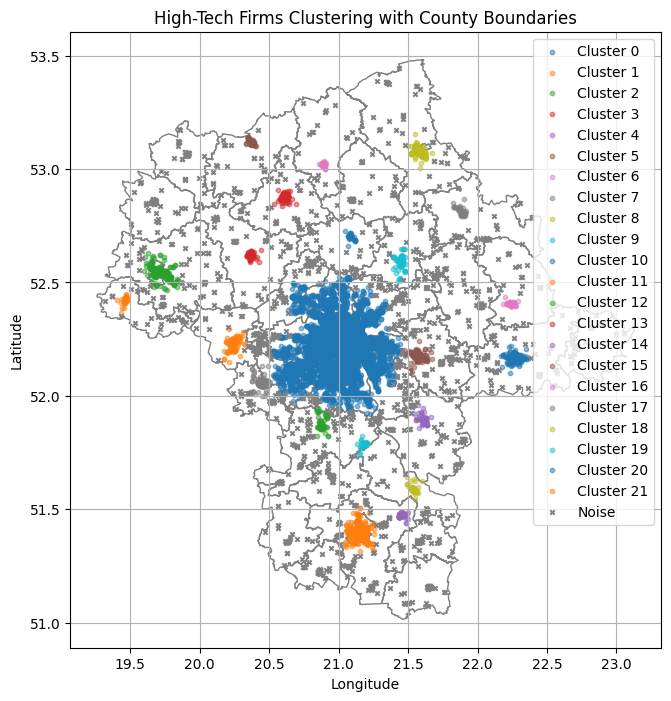

In [82]:
from sklearn.cluster import DBSCAN

# DBSCAN parameters
eps = 0.05  # Adjust according to your data
min_samples = 50  # Adjust according to your data

# DBSCAN clustering
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
X = gdf_ht[['lon', 'lat']].values
dbscan.fit(X)
labels = dbscan.labels_
unique_labels = np.unique(labels)

print("Labels:", labels)
print("Unique Labels:", unique_labels)

# Plotting
ax = powiaty_maz.plot(figsize=(12, 8), color='none', edgecolor='grey')

# Plot clusters of high-tech firms
for label in unique_labels:
    if label == -1:
        continue
    cluster_points = X[labels == label]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {label}', s=10, alpha=0.5)

# Plot noise points separately
noise_points = X[labels == -1]
plt.scatter(noise_points[:, 0], noise_points[:, 1], label='Noise', color='gray', marker='x', s=10)


plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('High-Tech Firms Clustering with County Boundaries')
plt.grid(True)

# Add legend for points only
plt.legend()

plt.show()

Grid high-tech Warsaw

In [84]:
min_lon_waw, max_lon_waw = warsaw['lon'].min(), warsaw['lon'].max()
min_lat_waw, max_lat_waw = warsaw['lat'].min(), warsaw['lat'].max()
grid_size = 0.01182  # Adjust as needed

lons_waw = np.arange(min_lon_waw, max_lon_waw, grid_size)
lats_waw = np.arange(min_lat_waw, max_lat_waw, grid_size)

warsaw_ht['grid_x_waw_ht'] = np.digitize(warsaw_ht['lon'], lons_waw)
warsaw_ht['grid_y_waw_ht'] = np.digitize(warsaw_ht['lat'], lats_waw)

grid_counts_waw = warsaw_ht.groupby(['grid_x_waw_ht', 'grid_y_waw_ht']).size().reset_index(name='firm_count_waw_ht')
warsaw_ht = warsaw_ht.merge(grid_counts_waw, how='left', on=['grid_x_waw_ht', 'grid_y_waw_ht'])

In [85]:
heatmap_waw = np.zeros((len(lats_waw), len(lons_waw)))

for idx, row in grid_counts_waw.iterrows():
    grid_x, grid_y = row['grid_x_waw_ht'] - 1, row['grid_y_waw_ht'] - 1  
    count = row['firm_count_waw_ht']
    heatmap_waw[grid_y, grid_x] = count

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


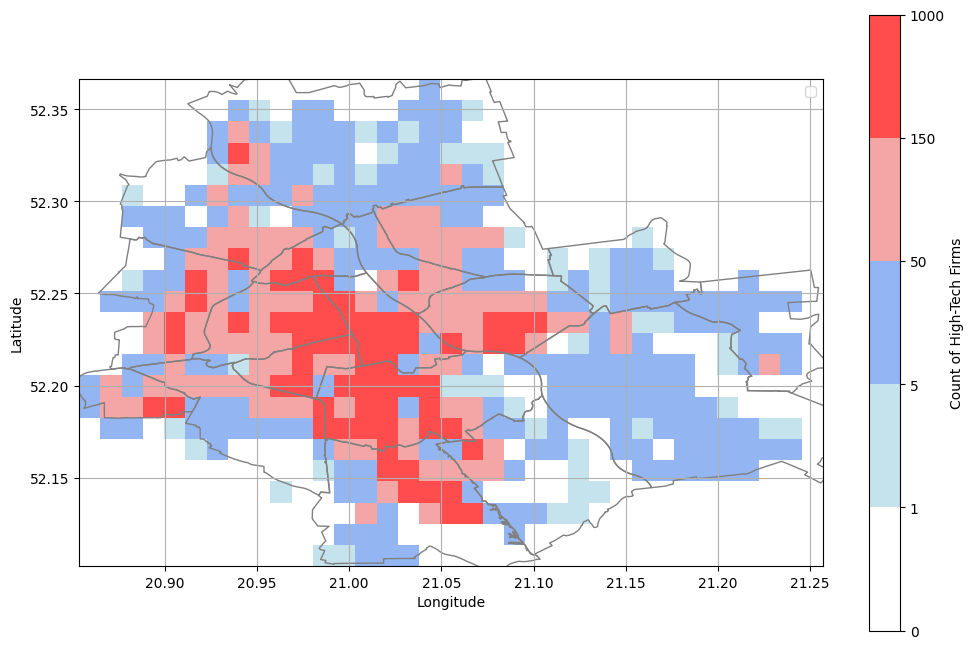

In [86]:
colors = ['white', 'lightblue', 'cornflowerblue', 'lightcoral', 'red']
bounds = [0, 1, 5, 50, 150, 1000]

cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, len(colors))

ax = dzielnice.plot(figsize=(12, 8), color='none', edgecolor='grey')

plt.imshow(heatmap_waw, cmap=cmap, norm=norm, origin='lower', extent=[min_lon_waw, max_lon_waw, min_lat_waw, max_lat_waw], alpha=0.7)

# plt.scatter(warsaw_ht['lon'], warsaw_ht['lat'], color='black', marker='o', s = 0.01)
plt.colorbar(label='Count of High-Tech Firms')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.legend()
plt.grid(True)
plt.show()

Grid maz non high-tech

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


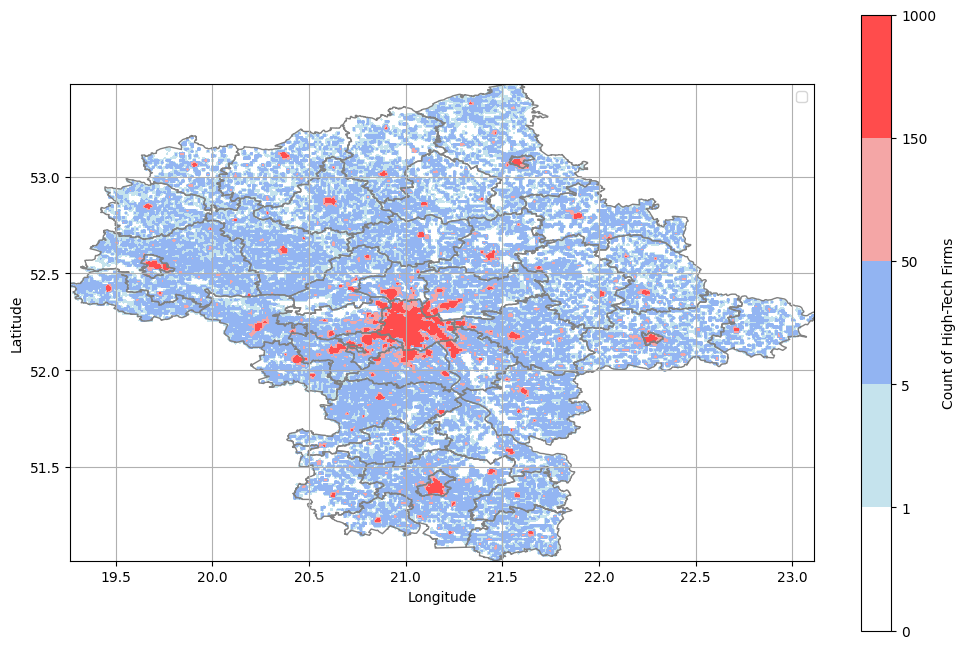

In [87]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy import stats

gdf_non_ht = gdf[gdf['if_hightech'] == 0]

min_lon, max_lon = gdf['lon'].min(), gdf['lon'].max()
min_lat, max_lat = gdf['lat'].min(), gdf['lat'].max()
grid_size = 0.01182 

lons = np.arange(min_lon, max_lon, grid_size)
lats = np.arange(min_lat, max_lat, grid_size)

gdf_non_ht['grid_x'] = np.digitize(gdf_non_ht['lon'], lons)
gdf_non_ht['grid_y'] = np.digitize(gdf_non_ht['lat'], lats)

grid_counts_non_ht = gdf_non_ht.groupby(['grid_x', 'grid_y']).size().reset_index(name='firm_count')

heatmap_non_ht= np.zeros((len(lats), len(lons)))

for idx, row in grid_counts_non_ht.iterrows():
    grid_x, grid_y = row['grid_x'] - 1, row['grid_y'] - 1  
    count = row['firm_count']
    heatmap_non_ht[grid_y, grid_x] = count

colors = ['white', 'lightblue', 'cornflowerblue', 'lightcoral', 'red']
bounds = [0, 1, 5, 50, 150, 1000]

cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, len(colors))

ax = powiaty_maz.plot(figsize=(12, 8), color='none', edgecolor='grey')

plt.imshow(heatmap_non_ht, cmap=cmap, norm=norm, origin='lower', extent=[min_lon, max_lon, min_lat, max_lat], alpha=0.7)

# plt.scatter(warsaw_ht['lon'], warsaw_ht['lat'], color='black', marker='o', s = 0.01)
plt.colorbar(label='Count of non High-Tech Firms')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.legend()
plt.grid(True)
plt.show()


Morans/G* trials


In [ ]:
import libpysal as lps
from esda.getisord import G_Local

w_queen = lps.weights.Queen.from_dataframe(gdf_ht)

gi_star = G_Local(gdf_ht['firm_count_maz_ht_x'], w_queen, transform='r', star=True)

z_scores = gi_star.z_sim
p_values = gi_star.p_sim

significance_threshold = 0.1

hotspot_mask = (z_scores > 0) & (p_values < significance_threshold)

gdf_ht['high_tech_hotspot'] = hotspot_mask.astype(int)


gdf_ht.plot(column='high_tech_hotspot', cmap='Reds', legend=True)
plt.title('High-Tech Firm Hotspots')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


In [92]:
from esda.moran import Moran

w_queen = lps.weights.Queen.from_dataframe(gdf_ht)

moran_i = Moran(gdf_ht['firm_count_maz_ht_x'], w_queen)

# Print Moran's I statistic and p-value
print("Moran's I:", moran_i.I)
print("P-value:", moran_i.p_sim)


Moran's I: 0.9868214310558794
P-value: 0.001


In [ ]:
from esda import G_Local

# Assuming you have already created a spatial weights matrix (w_distance) and have a variable of interest (e.g., 'firm_count_maz_ht')

# Create a G_Local instance
g_local = G_Local(gdf_ht['firm_count_maz_ht'], w_queen,transform='B')

# Get the Gi* statistics and p-values
g_star = g_local.Gs
p_values = g_local.p_sim

# Print Gi* statistics and p-values
print("Getis-Ord Gi* statistics:", g_star)
print("P-values:", p_values)


In [ ]:
import matplotlib.pyplot as plt

# Assuming you have a list or array of g_star values named g_star_values
# Replace g_star_values with your actual data
g_star_values = g_star

# Plot the histogram
plt.hist(g_star_values, bins=20, color='skyblue', edgecolor='black')

# Add labels and title
plt.xlabel('Gi* Values')
plt.ylabel('Frequency')
plt.title('Histogram of Gi* Values')

# Show the plot
plt.show()


Grid maz for defined groups

In [ ]:

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

min_lon_all, max_lon_all = gdf['lon'].min(), gdf['lon'].max()
min_lat_all, max_lat_all = gdf['lat'].min(), gdf['lat'].max()

def generate_heatmap_for_group(group_name):
    # Filter DataFrame for the specified group
    group_df = gdf[gdf['Group'] == group_name]
    
    # Calculate min and max values for lon and lat for the filtered DataFrame
    min_lon, max_lon = group_df['lon'].min(), group_df['lon'].max()
    min_lat, max_lat = group_df['lat'].min(), group_df['lat'].max()

    # Define grid size (adjust according to your needs)
    grid_size = 0.0093

    
    # Generate grid of lon and lat values
    lons = np.arange(min_lon_all, max_lon_all, grid_size)
    lats = np.arange(min_lat_all, max_lat_all, grid_size)
    
    # Digitize lon and lat values
    group_df['grid_x'] = np.digitize(group_df['lon'], lons)
    group_df['grid_y'] = np.digitize(group_df['lat'], lats)
    
    # Group by grid coordinates and count firms
    grid_counts = group_df.groupby(['grid_x', 'grid_y']).size().reset_index(name='firm_count')
    group_df = group_df.merge(grid_counts, how='left', on=['grid_x', 'grid_y'])


    # Create a copy of the merged DataFrame with a name like gdf_groupname
    globals()[f"gdf_{group_name}"] = group_df.copy()

    # Create heatmap matrix
    heatmap = np.zeros((len(lats), len(lons)))
    
    # Populate heatmap matrix with counts
    for idx, row in grid_counts.iterrows():
        grid_x, grid_y = row['grid_x'] - 1, row['grid_y'] - 1  
        count = row['firm_count']
        heatmap[grid_y, grid_x] = count

    city_lon = [21.017532, 21.14714, 19.70638, 22.29006, 21.5714]
    city_lat = [52.237049, 51.40253, 52.54682, 52.16772, 53.0813]
    city_names = ['Warsaw', 'Radom', 'Płock', 'Siedlce', 'Ostrołęka']

    # Define colors and bounds based on group_name
    colors = ['white', 'lightblue', 'cornflowerblue', 'lightcoral', 'red']
    if group_name in ['HTKIS', 'MLT', 'LT', 'MHT']:
        bounds = [0, 1, 5, 50, 150, 3000]
    elif group_name in ['O', 'KIS']:
        bounds = [0, 1, 30, 100, 400, 3000]
    else:
        bounds = [0, 1, 5, 15, 50, 300]

    cmap = ListedColormap(colors)
    norm = BoundaryNorm(bounds, len(colors))    
    
    # Plot heatmap
    plt.figure(figsize=(12, 8))
    ax = powiaty_maz.plot(figsize=(12, 8), color='none', edgecolor='grey')
    img = ax.imshow(heatmap, cmap=cmap, norm=norm, origin='lower', extent=[min_lon_all, max_lon_all, min_lat_all, max_lat_all], alpha=0.7)

    for city, lon, lat in zip(city_names, city_lon, city_lat):
        plt.annotate(city, xy=(lon, lat), xytext=(7, -2), textcoords='offset points', color='black', fontsize=10)

    plt.colorbar(img, label='Count of Firms')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Heatmap of {group_name} Firms')
    plt.grid(True)
    plt.show()


group_names = ['O', 'KIS', 'HTKIS', 'MLT', 'LT', 'MHT', 'HT', 'PMHT']

dfs = []

for group_name in group_names:
    generate_heatmap_for_group(group_name)
    dfs.append(globals()[f"gdf_{group_name}"])

gdf_counts= pd.concat(dfs, ignore_index=True)

In [106]:
gdf_counts

,?,ID,REGON,POWIAT,GMINA,Address_full,SEK_PKD7,PKD7,GR_LPRAC,lon,lat,tech,if_hightech,empl,sharesEMPL2,ones,locPdens,locAggA,locAggB,locAggC,locAggD,locAggE,locAggF,locAggG,locAggH,locAggI,locAggJ,locAggK,locAggL,locAggM,locAggN,locAggO,locAggP,locAggQ,locAggR,locAggS,locAggT,locAggU,locHH,locBIG,locAggTOTAL,locHightech,locLQ,dist_core_10,dist_core_25,dist_core_50,dist_midsize_10,dist_midsize_25,dist_midsize_50,dist_regional_10,dist_regional_25,dist_regional_50,dist_localbig_10,dist_localbig_25,dist_localbig_50,dist_localsmall_10,dist_localsmall_25,dist_localsmall_50,COREfirms,COREpopul,geometry,Group,grid_x,grid_y,firm_count
0,42342,1,1.406805e+13,17,44,Joachima Lelewela 27 05-480 Karczew,S,9499Z,1,21.23600,52.08347,other,0,5.034085,1.856614e-10,1,26,18,0,38,0,1,25,56,13,1,7,5,1,11,5,0,6,9,1,8,0,0,1.468536e-09,0,205,15,0.851179,0,1,1,0,0,0,0,0,1,1,1,1,0,1,1,1,1,POINT (21.23600 52.08347),O,212,115,18
1,42343,2,6.721748e+13,7,22,Rogożek 3 26-903 Rogożek,A,0150Z,1,21.36008,51.63636,other,0,5.035107,1.531587e-11,1,1,2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.994063e-11,0,3,0,2.586889,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,POINT (21.36008 51.63636),O,226,67,1
2,118240,3,1.109380e+12,65,58,Ignacego Krasickiego 12A 02-611 Warszawa,G,4690Z,1,21.02140,52.19191,other,0,5.001276,1.518227e-11,1,203,72,4,141,24,12,192,620,111,64,203,98,185,533,121,0,89,101,51,207,0,1,2.685278e-07,34,2829,183,1.126141,1,1,1,0,0,0,0,1,1,0,1,1,1,1,1,1,1,POINT (21.02140 52.19191),O,189,127,1009
3,210007,4,1.566525e+12,65,188,al. Prymasa Tysiąclecia 62 01-424 Warszawa,G,4643Z,1,20.95726,52.23474,other,0,5.114140,1.587524e-11,1,220,10,1,35,3,4,47,133,25,27,42,19,54,111,29,3,25,24,12,38,0,0,3.089481e-08,6,642,49,1.064512,1,1,1,0,0,0,0,1,1,0,1,1,0,1,1,1,1,POINT (20.95726 52.23474),O,183,132,1254
4,423483,7,1.261750e+12,65,118,Młodzieńcza 6A 03-655 Warszawa,G,4531Z,1,21.07405,52.28819,other,0,5.069210,1.559752e-11,1,63,39,1,189,4,3,146,583,139,37,127,48,58,209,65,1,58,59,24,103,0,0,6.196419e-08,14,1893,133,1.582529,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,POINT (21.07405 52.28819),O,195,137,577
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
983710,945597,982202,1.474953e+13,65,108,Grzybowska 2 00-131 Warszawa,D,3511Z,1,21.00289,52.23774,other,0,5.057311,2.481060e-08,1,219,107,14,349,49,28,509,1647,202,262,551,529,628,1448,287,8,165,188,106,564,0,9,2.206487e-03,105,7650,558,3.241227,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,POINT (21.00289 52.23774),PMHT,187,132,38
983711,945759,982318,1.410641e+13,65,68,Włodarzewska 4 02-384 Warszawa,D,3511Z,1,20.96751,52.20238,other,0,4.983639,2.409302e-08,1,254,79,2,126,21,3,207,606,188,62,181,111,133,385,141,1,85,110,41,148,0,1,5.098095e-07,13,2631,175,4.038994,1,1,1,0,0,0,0,1,1,0,1,1,0,1,1,1,1,POINT (20.96751 52.20238),PMHT,184,128,37
983712,947228,983212,1.461020e+13,65,108,Bagatela 10 00-585 Warszawa,D,3511Z,1,21.02325,52.21395,other,0,4.939712,2.367017e-08,1,162,64,20,184,26,6,252,688,111,125,291,172,362,1007,161,18,102,149,83,325,0,15,2.183974e-03,54,4161,272,3.161917,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,POINT (21.02325 52.21395),PMHT,190,129,23
983713,973244,983389,1.464965e+13,65,38,Głębocka 102 03-287 Warszawa,D,3511Z,1,21.06861,52.31850,other,0,4.960604,2.387081e-08,1,27,29,0,40,1,3,73,171,44,26,111,41,41,172,50,0,60,51,12,51,0,0,2.482309e-08,2,976,109,0.518472,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,POINT (21.06861 52.31850),PMHT,194,141,1


In [17]:
grid_distrib = gdf_counts.groupby(['grid_x', 'grid_y', 'Group'])['firm_count'].max()

In [100]:
# Aggregate firm counts for each group within each cell
grid_data_aggregated = gdf_counts.groupby(['grid_x', 'grid_y', 'Group'])['firm_count'].first().reset_index()

# Pivot the aggregated DataFrame to create separate columns for firm counts for each group in each cell
grid_data_pivoted = grid_data_aggregated.pivot_table(index=['grid_x', 'grid_y'], columns='Group', values='firm_count').reset_index()

# Fill NA with 0
grid_data_pivoted = grid_data_pivoted.fillna(0)

# Merge grid_data_pivoted with gdf_coutns
grid_data = gdf_counts.merge(grid_data_pivoted, on=['grid_x', 'grid_y'], how='left')

# Drop duplicated grid cells
grid_data = grid_data.drop_duplicates(subset=['grid_x', 'grid_y'])

# Sort the DataFrame by 'grid_x' and 'grid_y'
grid_data = grid_data.sort_values(['grid_x', 'grid_y'])

# Add a new column 'grid_xy' with the numbering of grid cells
grid_data['grid_xy'] = np.arange(1, grid_data.shape[0] + 1)

In [101]:
grid_data

,?,ID,REGON,POWIAT,GMINA,Address_full,SEK_PKD7,PKD7,GR_LPRAC,lon,lat,tech,if_hightech,empl,sharesEMPL2,ones,locPdens,locAggA,locAggB,locAggC,locAggD,locAggE,locAggF,locAggG,locAggH,locAggI,locAggJ,locAggK,locAggL,locAggM,locAggN,locAggO,locAggP,locAggQ,locAggR,locAggS,locAggT,locAggU,locHH,locBIG,locAggTOTAL,locHightech,locLQ,dist_core_10,dist_core_25,dist_core_50,dist_midsize_10,dist_midsize_25,dist_midsize_50,dist_regional_10,dist_regional_25,dist_regional_50,dist_localbig_10,dist_localbig_25,dist_localbig_50,dist_localsmall_10,dist_localsmall_25,dist_localsmall_50,COREfirms,COREpopul,geometry,Group,grid_x,grid_y,firm_count,HT,HTKIS,KIS,LT,MHT,MLT,O,PMHT,grid_xy
19296,688738,26532,6.111710e+13,4,22,Gulewo 4 09-500 Gulewo,A,0150Z,1,19.266647,52.438775,other,0,4.930172,1.468414e-11,1,0,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.219284e-10,0,8,0,3.880334,0,0,0,0,0,1,0,0,0,0,0,0,1,1,1,0,0,POINT (19.26665 52.43877),O,1,154,9,0.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,1
51728,1132051,70864,6.111710e+13,4,22,Gulewo 27 09-500 Gulewo,A,0150Z,1,19.266907,52.448436,other,0,5.062161,1.548090e-11,1,3,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6.083349e-11,0,4,0,3.880334,0,0,0,0,0,1,0,0,0,0,0,0,1,1,1,0,0,POINT (19.26691 52.44844),O,1,155,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2
105631,186757,144416,6.111745e+13,4,22,Niecki 20 09-500 Niecki,A,0150Z,1,19.282125,52.404212,other,0,4.939673,1.474079e-11,1,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.957998e-11,0,2,0,3.880334,0,0,0,0,0,1,0,0,0,0,0,0,1,1,1,0,0,POINT (19.28213 52.40421),O,2,150,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3
306537,461660,419319,6.111706e+13,4,22,Gulewo 11 09-500 Gulewo,A,0150Z,1,19.279237,52.441487,other,0,5.046304,1.538406e-11,1,3,4,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,6.105983e-11,0,5,0,3.104267,0,0,0,0,0,1,0,0,0,0,0,0,1,1,1,0,0,POINT (19.27924 52.44149),O,2,154,3,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,4
141505,235924,193583,6.111710e+13,4,22,Gulewo 24 09-500 Gulewo,A,0150Z,1,19.274273,52.448813,other,0,4.982161,1.499546e-11,1,3,2,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,3.086496e-11,0,3,0,2.586889,0,0,0,0,0,1,0,0,0,0,0,0,1,1,1,0,0,POINT (19.27427 52.44881),O,2,155,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,291000,214,7.117395e+13,10,52,Borsuki 86 08-221 Borsuki,A,0150Z,1,23.090830,52.264270,other,0,4.948474,1.479336e-11,1,1,155,1,7,0,1,14,43,14,4,1,2,4,4,2,1,4,3,0,7,0,0,1.590155e-08,2,267,2,2.252628,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,POINT (23.09083 52.26427),O,412,135,17,0.0,0.0,0.0,0.0,0.0,0.0,17.0,0.0,35368
328519,643701,449392,7.117393e+13,10,52,Borsuki 62 08-221 Borsuki,A,0150Z,1,23.096640,52.270360,other,0,4.996976,1.508477e-11,1,1,461,0,28,3,1,38,102,28,7,5,9,11,22,6,4,16,22,2,19,0,0,6.959384e-09,2,784,6,2.281676,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,POINT (23.09664 52.27036),O,413,135,1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,35369
32776,6372,45006,7.117393e+13,10,52,Borsuki 2 08-221 Borsuki,A,0150Z,1,23.097490,52.271350,other,0,4.993794,1.506557e-11,1,1,6,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,8.990434e-11,0,9,0,2.586889,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,POINT (23.09749 52.27135),O,413,136,36,0.0,0.0,0.0,0.0,0.0,0.0,36.0,0.0,35370
44081,8601,60377,1.423175e+13,10,52,Borsuki 14A 08-221 Borsuki,G,4711Z,1,23.105280,52.280200,other,0,5.053965,1.550385e-11,1,0,22,0,3,0,0,2,8,2,0,0,1,1,2,0,0,2,1,0,1,0,0,1.215156e-10,0,45,0,0.913506,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,POINT (23.10528 52.28020),O,413,137,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,35371


In [102]:
grid_counts = grid_data.iloc[:, 64:]

In [103]:
grid_counts

,firm_count,HT,HTKIS,KIS,LT,MHT,MLT,O,PMHT,grid_xy
19296,9,0.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,1
51728,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2
105631,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3
306537,3,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,4
141505,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,5
...,...,...,...,...,...,...,...,...,...,...
160,17,0.0,0.0,0.0,0.0,0.0,0.0,17.0,0.0,35368
328519,1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,35369
32776,36,0.0,0.0,0.0,0.0,0.0,0.0,36.0,0.0,35370
44081,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,35371


In [56]:
# Step 1: Calculate the total count of firms for each group
total_firms_per_group = grid_data['HT'].sum()
total_firms_per_group

2173.0

In [ ]:
groups = ['HTKIS', 'MLT', 'LT', 'MHT', 'O', 'KIS', 'HT']

for group in groups:
    globals()[f"total_firms_{group}"] = grid_data[group].sum()
    



In [38]:
# Step 1: Calculate the total count of firms for each group
total_firms_per_group = grid_data['HT'].sum()

# Step 2: Calculate the total count of high-tech firms for the entire study area
total_high_tech_firms = gdf_counts[gdf_counts['Group'] == 'HT']['firm_count'].sum()

# Step 3: Calculate the proportion of high-tech firms in each group
gdf_counts['proportion_high_tech'] = gdf_counts.apply(lambda row: row['firm_count'] / total_firms_per_group[row['Group']], axis=1)

# Step 4: Calculate the proportion of high-tech firms in the entire study area
proportion_high_tech_study_area = total_high_tech_firms / gdf_counts['firm_count'].sum()

# Step 5: Compute the Location Quotient for each group
gdf_counts['location_quotient'] = gdf_counts['proportion_high_tech'] / proportion_high_tech_study_area

# Display the resulting DataFrame with Location Quotient for each group
print(gdf_counts[['Group', 'location_quotient']])


,?,ID,REGON,POWIAT,GMINA,Address_full,SEK_PKD7,PKD7,GR_LPRAC,lon,lat,tech,if_hightech,empl,sharesEMPL2,ones,locPdens,locAggA,locAggB,locAggC,locAggD,locAggE,locAggF,locAggG,locAggH,locAggI,locAggJ,locAggK,locAggL,locAggM,locAggN,locAggO,locAggP,locAggQ,locAggR,locAggS,locAggT,locAggU,locHH,locBIG,locAggTOTAL,locHightech,locLQ,dist_core_10,dist_core_25,dist_core_50,dist_midsize_10,dist_midsize_25,dist_midsize_50,dist_regional_10,dist_regional_25,dist_regional_50,dist_localbig_10,dist_localbig_25,dist_localbig_50,dist_localsmall_10,dist_localsmall_25,dist_localsmall_50,COREfirms,COREpopul,geometry,Group,grid_x,grid_y,firm_count,HT,HTKIS,KIS,LT,MHT,MLT,O,PMHT,grid_xy
19296,688738,26532,6.111710e+13,4,22,Gulewo 4 09-500 Gulewo,A,0150Z,1,19.266647,52.438775,other,0,4.930172,1.468414e-11,1,0,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.219284e-10,0,8,0,3.880334,0,0,0,0,0,1,0,0,0,0,0,0,1,1,1,0,0,POINT (19.26665 52.43877),O,1,154,9,0.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,1
51728,1132051,70864,6.111710e+13,4,22,Gulewo 27 09-500 Gulewo,A,0150Z,1,19.266907,52.448436,other,0,5.062161,1.548090e-11,1,3,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6.083349e-11,0,4,0,3.880334,0,0,0,0,0,1,0,0,0,0,0,0,1,1,1,0,0,POINT (19.26691 52.44844),O,1,155,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2
105631,186757,144416,6.111745e+13,4,22,Niecki 20 09-500 Niecki,A,0150Z,1,19.282125,52.404212,other,0,4.939673,1.474079e-11,1,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.957998e-11,0,2,0,3.880334,0,0,0,0,0,1,0,0,0,0,0,0,1,1,1,0,0,POINT (19.28213 52.40421),O,2,150,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3
306537,461660,419319,6.111706e+13,4,22,Gulewo 11 09-500 Gulewo,A,0150Z,1,19.279237,52.441487,other,0,5.046304,1.538406e-11,1,3,4,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,6.105983e-11,0,5,0,3.104267,0,0,0,0,0,1,0,0,0,0,0,0,1,1,1,0,0,POINT (19.27924 52.44149),O,2,154,3,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,4
141505,235924,193583,6.111710e+13,4,22,Gulewo 24 09-500 Gulewo,A,0150Z,1,19.274273,52.448813,other,0,4.982161,1.499546e-11,1,3,2,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,3.086496e-11,0,3,0,2.586889,0,0,0,0,0,1,0,0,0,0,0,0,1,1,1,0,0,POINT (19.27427 52.44881),O,2,155,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,291000,214,7.117395e+13,10,52,Borsuki 86 08-221 Borsuki,A,0150Z,1,23.090830,52.264270,other,0,4.948474,1.479336e-11,1,1,155,1,7,0,1,14,43,14,4,1,2,4,4,2,1,4,3,0,7,0,0,1.590155e-08,2,267,2,2.252628,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,POINT (23.09083 52.26427),O,412,135,17,0.0,0.0,0.0,0.0,0.0,0.0,17.0,0.0,35368
328519,643701,449392,7.117393e+13,10,52,Borsuki 62 08-221 Borsuki,A,0150Z,1,23.096640,52.270360,other,0,4.996976,1.508477e-11,1,1,461,0,28,3,1,38,102,28,7,5,9,11,22,6,4,16,22,2,19,0,0,6.959384e-09,2,784,6,2.281676,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,POINT (23.09664 52.27036),O,413,135,1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,35369
32776,6372,45006,7.117393e+13,10,52,Borsuki 2 08-221 Borsuki,A,0150Z,1,23.097490,52.271350,other,0,4.993794,1.506557e-11,1,1,6,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,8.990434e-11,0,9,0,2.586889,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,POINT (23.09749 52.27135),O,413,136,36,0.0,0.0,0.0,0.0,0.0,0.0,36.0,0.0,35370
44081,8601,60377,1.423175e+13,10,52,Borsuki 14A 08-221 Borsuki,G,4711Z,1,23.105280,52.280200,other,0,5.053965,1.550385e-11,1,0,22,0,3,0,0,2,8,2,0,0,1,1,2,0,0,2,1,0,1,0,0,1.215156e-10,0,45,0,0.913506,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,POINT (23.10528 52.28020),O,413,137,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,35371


In [ ]:
# Compute descriptive statistics for firm counts by group
descriptive_stats = grid_data.groupby('HT').describe()

# Print descriptive statistics
print(descriptive_stats)


In [ ]:
# Pivot the aggregated DataFrame to create separate columns for firm counts for each group in each cell
grid_data_pivoted = grid_data_aggregated.pivot_table(index=['grid_x', 'grid_y'], columns='Group', values='firm_count').reset_index()
grid_data_pivoted

In [ ]:
grid_data_pivoted = grid_data_pivoted.fillna(0)
grid_data_pivoted

In [ ]:
grid_data = gdf_counts.merge(grid_data_pivoted, on=['grid_x', 'grid_y'], how='left')
grid_data

In [ ]:
grid_data = grid_data.drop_duplicates(subset=['grid_x', 'grid_y'])

In [ ]:
# Sort the DataFrame by 'grid_x' and 'grid_y'
grid_data = grid_data.sort_values(['grid_x', 'grid_y'])

# Add a new column 'grid_xy' with the numbering of grid cells
grid_data['grid_xy'] = np.arange(1, grid_data.shape[0] + 1)

In [ ]:
import matplotlib.pyplot as plt

# Assuming powiaty_maz is a GeoDataFrame
plt.figure(figsize=(12, 8))
ax = powiaty_maz.plot(color='none', edgecolor='grey', figsize=(12, 8))

# Assuming grid_data is another GeoDataFrame or DataFrame that you want to overlay
# If it's a GeoDataFrame, specify its geometry column
ax = grid_data.plot(ax=ax, markersize=0.1)

plt.show()


In [ ]:
grid_data = gdf_counts.drop_duplicates(subset=['grid_x', 'grid_y'])

In [ ]:
# Sort the DataFrame by 'grid_x' and 'grid_y'
grid_data = grid_data.sort_values(['grid_x', 'grid_y'])

# Add a new column 'grid_xy' with the numbering of grid cells
grid_data['grid_xy'] = np.arange(1, grid_data.shape[0] + 1)

In [ ]:
grid_data

In [ ]:
# Step 1: Calculate the total count of firms for each group
total_firms_per_group = gdf_counts.groupby('Group').size()

# Step 2: Calculate the total count of high-tech firms for the entire study area
total_high_tech_firms = gdf_counts[gdf_counts['Group'] == 'HT']['firm_count'].sum()

# Step 3: Calculate the proportion of high-tech firms in each group
gdf_counts['proportion_high_tech'] = gdf_counts.apply(lambda row: row['firm_count'] / total_firms_per_group[row['Group']], axis=1)

# Step 4: Calculate the proportion of high-tech firms in the entire study area
proportion_high_tech_study_area = total_high_tech_firms / gdf_counts['firm_count'].sum()

# Step 5: Compute the Location Quotient for each group
gdf_counts['location_quotient'] = gdf_counts['proportion_high_tech'] / proportion_high_tech_study_area

# Display the resulting DataFrame with Location Quotient for each group
print(gdf_counts[['Group', 'location_quotient']])


In [ ]:
total_high_tech_firms = gdf_counts[gdf_counts['Group'] == 'HT']['firm_count'].sum()

In [ ]:
gdf_counts[gdf_counts['Group'].isin(['HT', 'HTKIS', 'MHT'])]['firm_count'].sum()

In [ ]:
total_firms_per_group = gdf_counts.groupby('Group').size()

In [ ]:
total_firms_per_group

In [ ]:
dfs_ht = [gdf_HT, gdf_HTKIS, gdf_MHT]

gdf_ht_counts = pd.concat(dfs_ht, ignore_index=True)

In [ ]:
gdf_ht.head()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

predictors = ['locHH', 'lon', 'lat', 'empl', 'sharesEMPL2', 'locPdens', 'locBIG', 'locAggTOTAL', 'locHightech', 'locLQ', 'dist_core_10', 
              'dist_core_25', 'dist_core_50', 'dist_midsize_10', 'dist_midsize_25', 'dist_midsize_50', 'dist_regional_10', 'dist_regional_25', 
              'dist_regional_50', 'dist_localbig_10', 'dist_localbig_25', 'dist_localbig_50', 'dist_localsmall_10', 'dist_localsmall_25', 'dist_localsmall_50']

y = gdf['if_hightech']
X = gdf[predictors]


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the Random Forest Classifier model
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Evaluate the model
y_pred = rf_classifier.predict(X_test)
print(classification_report(y_test, y_pred))


In [ ]:
# Get feature importances from the trained model
feature_importances = rf_classifier.feature_importances_

# Create a DataFrame to store feature names and their importances
feature_importance_df = pd.DataFrame({'Feature': predictors, 'Importance': feature_importances})

# Sort the DataFrame by importance values in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Print the top N most important features
print("Top 10 Most Important Features:")
print(feature_importance_df.head(10))

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:10], feature_importance_df['Importance'][:10])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Most Important Features')
plt.gca().invert_yaxis()  # Invert y-axis to display the most important features at the top
plt.show()


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = rf_classifier.predict(X_test)
confusion_matrix(y_test, y_pred)

In [ ]:
import scikit-plot as skplt


skplt.metrics.plot_confusion_matrix(y_train, y_pred)


In [ ]:
import geopandas as gpd
from pysal.lib import weights
from pysal.explore import esda
import matplotlib.pyplot as plt
from splot.esda import plot_moran


group_names = gdf_counts['Group'].unique()

for group_name in group_names:

    group_df = gdf_counts[gdf_counts['Group'] == group_name]
    w = weights.Queen.from_dataframe(group_df)
    moran = esda.Moran(group_df['firm_count'], w)
    
    print(f"\nMoran's I for {group_name}:")
    print("Moran's I:", moran.I)
    print("Moran's I p-value:", moran.p_sim)

Heatmaps of all the groups for grid 1, 2, 5km

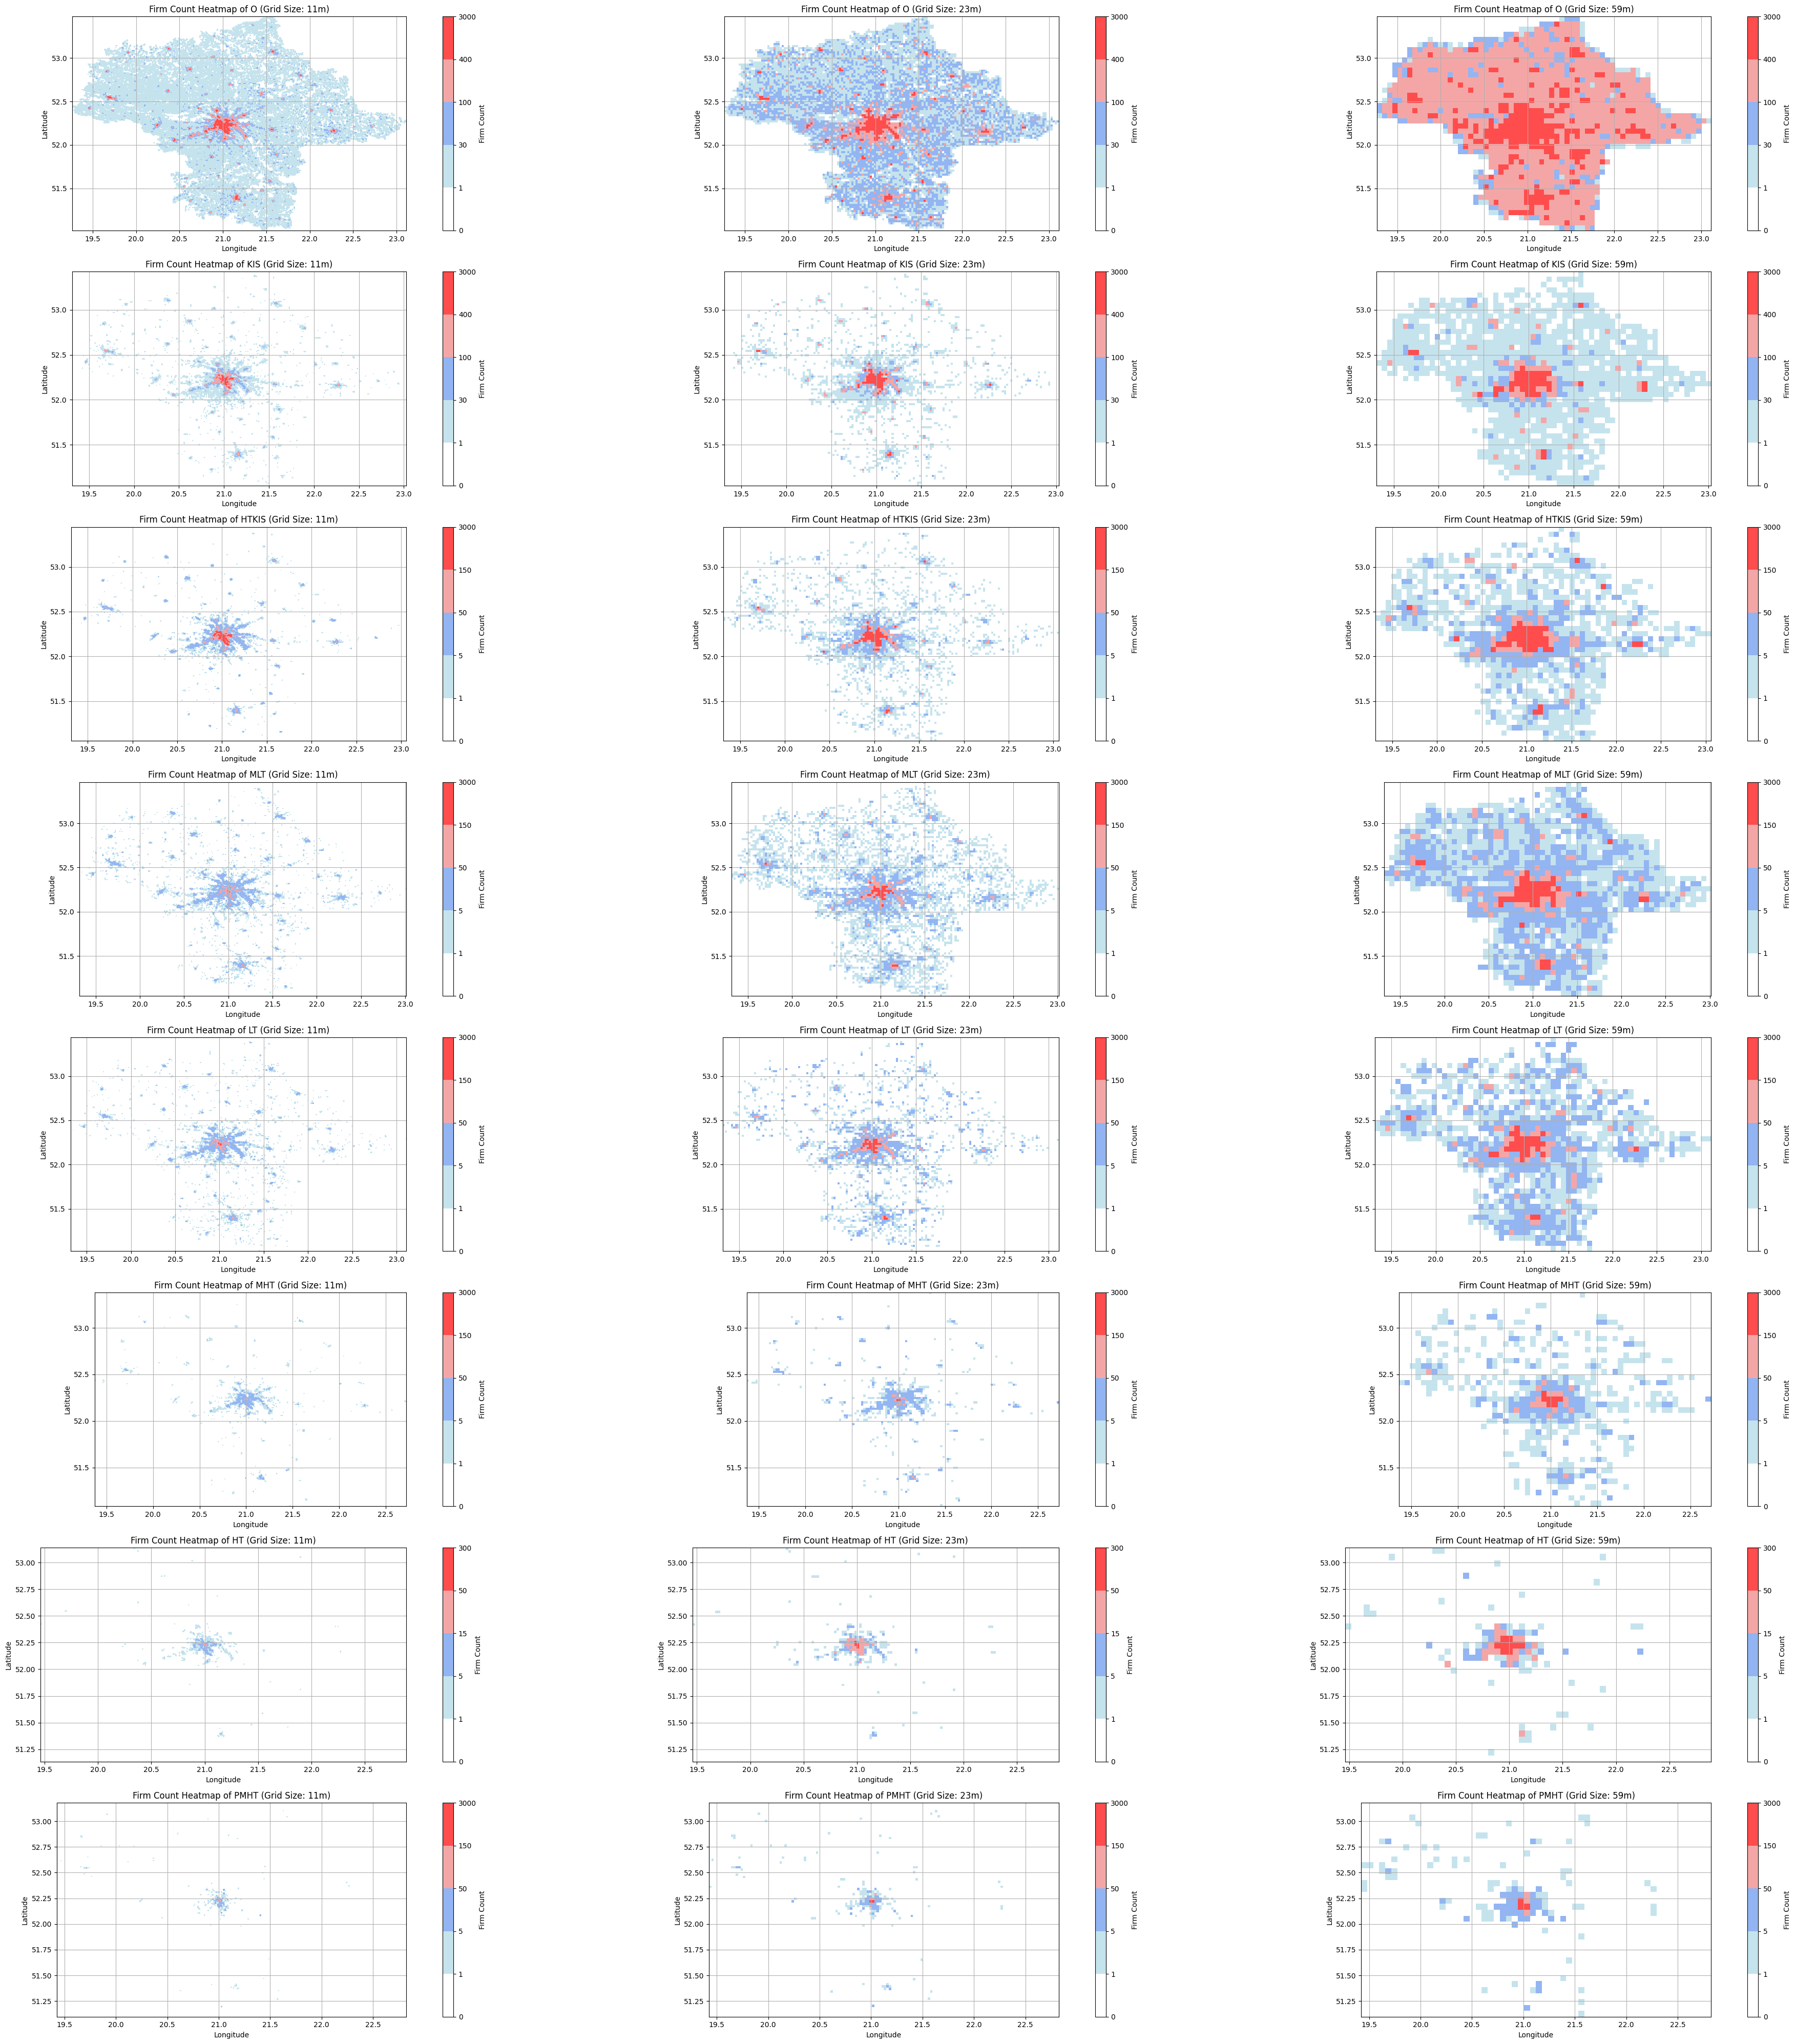

In [98]:
def generate_heatmap_for_group(group_name, grid_size, ax):
    # Filter DataFrame for the specified group
    group_df = gdf[gdf['Group'] == group_name]
    
    # Calculate min and max values for lon and lat for the filtered DataFrame
    min_lon, max_lon = group_df['lon'].min(), group_df['lon'].max()
    min_lat, max_lat = group_df['lat'].min(), group_df['lat'].max()
    
    
    # Generate grid of lon and lat values
    lons = np.arange(min_lon, max_lon, grid_size)
    lats = np.arange(min_lat, max_lat, grid_size)
    
    # Digitize lon and lat values
    group_df['grid_x'] = np.digitize(group_df['lon'], lons)
    group_df['grid_y'] = np.digitize(group_df['lat'], lats)
    
    # Group by grid coordinates and count firms
    grid_counts = group_df.groupby(['grid_x', 'grid_y']).size().reset_index(name='firm_count')
    group_df = group_df.merge(grid_counts, how='left', on=['grid_x', 'grid_y'])

    # Create a copy of the merged DataFrame with a name like gdf_groupname_gridsize
    globals()[f"gdf_{group_name}_{int(grid_size*1000)}m"] = group_df.copy()

    # Create heatmap matrix
    heatmap = np.zeros((len(lats), len(lons)))
    
    # Populate heatmap matrix with counts
    for idx, row in grid_counts.iterrows():
        grid_x, grid_y = row['grid_x'] - 1, row['grid_y'] - 1  
        count = row['firm_count']
        heatmap[grid_y, grid_x] = count

    # Define colors and bounds based on group_name
    colors = ['white', 'lightblue', 'cornflowerblue', 'lightcoral', 'red']
    if group_name in ['HTKIS', 'MLT', 'LT', 'MHT', 'PMHT']:
        bounds = [0, 1, 5, 50, 150, 3000]
    elif group_name in ['O', 'KIS']:
        bounds = [0, 1, 30, 100, 400, 3000]
    else:
        bounds = [0, 1, 5, 15, 50, 300]

    cmap = ListedColormap(colors)
    norm = BoundaryNorm(bounds, len(colors))    
    
    # Plot heatmap
    img = ax.imshow(heatmap, cmap=cmap, norm=norm, origin='lower', extent=[min_lon, max_lon, min_lat, max_lat], alpha=0.7)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'Firm Count Heatmap of {group_name} (Grid Size: {int(grid_size*1000)}m)')
    ax.grid(True)
    plt.colorbar(img, ax=ax, label='Firm Count')


# Define grid configurations
grid_sizes = [0.01182, 0.02365, 0.05912]  # Grid sizes in degrees (1km, 2km, and 5km)

# Create subplots for each group with different grid configurations
fig, axes = plt.subplots(len(group_names), len(grid_sizes), figsize=(40,40))

# Generate heatmap for each group with different grid configurations
for i, group_name in enumerate(group_names):
    for j, grid_size in enumerate(grid_sizes):
        ax = axes[i, j]
        generate_heatmap_for_group(group_name, grid_size, ax)

plt.tight_layout()
plt.show()
